In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [4]:
def func1(x, y):
    return x ** 2 - y ** 2

In [5]:
def func2(x, y):
    return x ** 2 + 2 * x * y + 3 * y ** 2

In [6]:
def hes(f, x, y, h):
    return ((f(x+h, y+ h) - f(x + h, y - h) - f(x - h, y + h) + f(x - h, y - h))/(4 * h ** 2))

In [7]:
def diag1(f, x, y, h):
    return (f(x + h, y) - 2 * f(x, y) + f(x - h, y)) / (h ** 2)

In [8]:
def diag2(f, x, y, h):
    return (f(x, y + h) - 2 * f(x, y) + f(x, y - h)) / (h ** 2)

In [9]:
hes(func1, 1, 2, 1e-6)

0.0

In [10]:
diag1(func1, 1, 2, 1e-6)

1.999733711954832

In [11]:
diag2(func1, 1, 2, 1e-6)

-2.001065979584382

In [12]:
diag1(func2, 1, 2, 1e-6)

2.000177801164682

In [13]:
diag2(func2, 1, 2, 1e-6)

6.000533403494046

In [14]:
hes(func2, 1, 2, 1e-6)

2.000177801164682

In [15]:
hes1 = np.array([[2, 0],
                [0, -2]])
np.linalg.eigvals(hes1)

array([ 2., -2.])

In [16]:
hes2 = np.array([[2, 2],
                [2, 6]])
np.linalg.eigvals(hes2)

array([1.17157288, 6.82842712])

In [17]:
x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)
Z = X ** 2 - Y ** 2

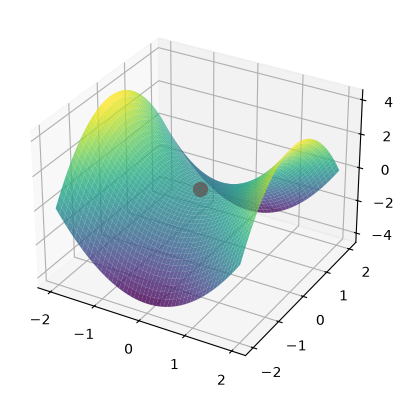

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, Z, cmap = 'viridis', alpha = 0.8)
ax.scatter(0, 0, 0, color = 'red', s = 100)

In [20]:
def graddesc(x, eta, itera):
    for i in range(itera):
        grad = np.array([2 * x[0] + 2 * x[1], 2 * x[0] + 6 * x[1]])
        x = x - eta * grad
    return x

x = np.array([3.0, 3.0])
graddesc(x, 0.1, 50)

array([ 0.00295296, -0.00122316])

In [27]:
def newton(x, itera):
    for i in range(itera):
        grad = np.array([2 * x[0] + 2 * x[1], 2 * x[0] + 6 * x[1]])
        x = x - np.linalg.inv(hes2) @ grad
    return x

x = np.array([3.0, 3.0])
newton(x, 1)

array([0., 0.])